# Weather Events and Market Response 
## Preprocessing and Modeling

# Table of Contents
- [Data Cleaning](#data-cleaning)
- [Feature Engineering](#feature-engineering)
- [Modeling](#modeling)
- [Results & Conclusion](#results--conclusion)


## Data Cleaning

In [786]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn import linear_model, preprocessing
from statsmodels.graphics.tsaplots import plot_acf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from tensorflow.keras import Sequential
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import learning_curve
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import itertools
import statsmodels.api as sm

In [787]:
fred = pd.read_csv('fred_tot.csv')
weather = pd.read_csv('weather.csv')

Our features need to be numeric for our model. We need to convert the 'Property Damage' column from object to numeric. In order to do this, we first must remove the letters and add zeros (example: 2.5k = 2500). Below is a function that will easily do this for us. 

In [789]:
def convert_letter(val):
    if isinstance(val, str): 
        val = val.strip().lower()
        try:
            if len(val) == 0: 
                return 0
            elif val == 'k':
                return 1_000
            elif val == 'm':
                return 1_000_000
            elif val == 'b':
                return 1_000_000_000
            elif val.endswith('k'):
                return int(float(val[:-1]) * 1_000)
            elif val.endswith('m'):
                return int(float(val[:-1]) * 1_000_000)
            elif val.endswith('b'):
                return int(float(val[:-1]) * 1_000_000_000)
            else:
                return float(val)
        except ValueError:
            return np.nan 
    elif isinstance(val, (int, float)):
        return val
    elif val is None:
        return np.nan
    else:
        return np.nan

In [790]:
weather['Property Damage'] = weather['Property Damage'].apply(convert_letter)

To make the data easier to manage and model, we will be aggregating our columns. This will give us daily cumulative values for our weather data.

In [792]:
daily_summary = weather.groupby('observation_date').agg({
    'Property Damage': 'sum',
    'Total Injuries and Deaths': 'sum',
    'Event Type': 'count'
}).rename(columns={
    'Event Type': 'num_events'
})

In [793]:
df = pd.merge(fred, daily_summary, on='observation_date', how='outer')
df.head()

,observation_date,GDPC1,ICSA,Inflation,UNRATE,SP500,DRCCLACBS,DTWEXBGS,FEDFUNDS,IMPGS,INDPRO,PERMIT,TCU,VIXCLS,Property Damage,Total Injuries and Deaths,num_events
0,1950-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3025000.0,7.0,4.0
1,1950-01-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2500.0,2.0,1.0
2,1950-01-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500000.0,5.0,2.0
3,1950-01-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2.0,1.0
4,1950-02-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,550000.0,24.0,4.0


We will be doing regression models first, so the date will be a feature rather than the index. The indexes and weather events aren't always recorded daily, we now we will be filling in missing days as to make it continuous. It is fine to forward fill market index values, but weather data being forward filled would be misleading. It would make it seem like our weather events occured on days they did not happen. To avoid this, we will simply replace NaNs with 0 for all weather related NaNs.

In [795]:
df['observation_date'].dtypes

dtype('O')

In [796]:
df['observation_date'] = pd.to_datetime(df['observation_date'])
df['observation_date'].dtypes

dtype('<M8[ns]')

This earliest date the columns have in common, '2015-10-01'. We will drop all rows before this date.  

In [798]:
df = df[df['observation_date'] >= '2015-10-01']

In [799]:
df.head(3)

,observation_date,GDPC1,ICSA,Inflation,UNRATE,SP500,DRCCLACBS,DTWEXBGS,FEDFUNDS,IMPGS,INDPRO,PERMIT,TCU,VIXCLS,Property Damage,Total Injuries and Deaths,num_events
17284,2015-10-01,18892.206,272000.0,0.118627,5.0,1923.82,2.16,111.0439,0.12,2745.517,100.1563,1160.0,76.752,22.55,11161550.0,2.0,190.0
17285,2015-10-02,18892.206,272000.0,0.118627,5.0,1951.36,2.16,110.7006,0.12,2745.517,100.1563,1160.0,76.752,20.94,25114500.0,3.0,112.0
17286,2015-10-03,18892.206,267000.0,0.118627,5.0,1951.36,2.16,110.7006,0.12,2745.517,100.1563,1160.0,76.752,NaN,51188540.0,3.0,114.0


Let's reset the index. 

In [801]:
df = df.reset_index(drop=True)
df.head()

,observation_date,GDPC1,ICSA,Inflation,UNRATE,SP500,DRCCLACBS,DTWEXBGS,FEDFUNDS,IMPGS,INDPRO,PERMIT,TCU,VIXCLS,Property Damage,Total Injuries and Deaths,num_events
0,2015-10-01,18892.206,272000.0,0.118627,5.0,1923.82,2.16,111.0439,0.12,2745.517,100.1563,1160.0,76.752,22.55,11161550.0,2.0,190.0
1,2015-10-02,18892.206,272000.0,0.118627,5.0,1951.36,2.16,110.7006,0.12,2745.517,100.1563,1160.0,76.752,20.94,25114500.0,3.0,112.0
2,2015-10-03,18892.206,267000.0,0.118627,5.0,1951.36,2.16,110.7006,0.12,2745.517,100.1563,1160.0,76.752,NaN,51188540.0,3.0,114.0
3,2015-10-04,18892.206,267000.0,0.118627,5.0,1951.36,2.16,110.7006,0.12,2745.517,100.1563,1160.0,76.752,NaN,88252280.0,35.0,135.0
4,2015-10-05,18892.206,267000.0,0.118627,5.0,1987.05,2.16,110.4445,0.12,2745.517,100.1563,1160.0,76.752,19.54,3582000.0,3.0,39.0


Not all recorded weather events will be economically impactful. Here we will create a column that flags days with meaningful weather events.

In [803]:
df['flagged_event'] = ((df['Property Damage'] > 100000) & (df['num_events'] >= 1)).astype(int)
df.isnull().sum()

observation_date                0
GDPC1                         570
ICSA                          570
Inflation                     570
UNRATE                        570
SP500                           0
DRCCLACBS                     204
DTWEXBGS                        6
FEDFUNDS                       53
IMPGS                         204
INDPRO                         53
PERMIT                         53
TCU                            53
VIXCLS                       1024
Property Damage              1396
Total Injuries and Deaths    1396
num_events                   1396
flagged_event                   0
dtype: int64

Now we will be forward filling null values for the market indexes. Weather NaNs will be set to sero. 

In [805]:
df[['GDPC1', 'ICSA', 'Inflation', 'UNRATE', 'SP500', 'DRCCLACBS', 
                      'DTWEXBGS', 'FEDFUNDS', 'IMPGS', 'INDPRO', 'PERMIT', 'TCU', 'VIXCLS']]= df[['GDPC1', 'ICSA', 'Inflation', 'UNRATE', 'SP500', 'DRCCLACBS', 
                      'DTWEXBGS', 'FEDFUNDS', 'IMPGS', 'INDPRO', 'PERMIT', 'TCU', 'VIXCLS']].ffill()
df[['Property Damage', 'Total Injuries and Deaths', 'num_events']] = df[['Property Damage', 'Total Injuries and Deaths', 'num_events']].fillna(0)

In [806]:
df.isnull().sum()

observation_date             0
GDPC1                        0
ICSA                         0
Inflation                    0
UNRATE                       0
SP500                        0
DRCCLACBS                    0
DTWEXBGS                     0
FEDFUNDS                     0
IMPGS                        0
INDPRO                       0
PERMIT                       0
TCU                          0
VIXCLS                       0
Property Damage              0
Total Injuries and Deaths    0
num_events                   0
flagged_event                0
dtype: int64

## Feature Engineering

In [808]:
df_pct = df[['GDPC1', 'ICSA', 'Inflation', 'UNRATE', 'SP500', 'DRCCLACBS', 
                      'DTWEXBGS', 'FEDFUNDS', 'IMPGS', 'INDPRO', 'PERMIT', 'TCU', 'VIXCLS']].pct_change()
df_pct.head()

,GDPC1,ICSA,Inflation,UNRATE,SP500,DRCCLACBS,DTWEXBGS,FEDFUNDS,IMPGS,INDPRO,PERMIT,TCU,VIXCLS
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,0.000000,0.0,0.0,0.014315,0.0,-0.003092,0.0,0.0,0.0,0.0,0.0,-0.071397
2,0.0,-0.018382,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000
3,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000
4,0.0,0.000000,0.0,0.0,0.018290,0.0,-0.002313,0.0,0.0,0.0,0.0,0.0,-0.066858


Let's make sure that it's not zero for all rows in 'Inflation'. If all is good we will merge it to our previous dataframe. 

In [810]:
df_pct['Inflation'].unique()

array([        nan,  0.        ,  9.63486191,  0.68844195,  0.1466935 ,
       -0.25807645, -0.31929283,  2.80829952,  0.70349941, -0.48563772,
       -0.283459  ])

In [811]:
cols = ['GDPC1', 'ICSA', 'Inflation', 'UNRATE', 'SP500', 'DRCCLACBS', 
                      'DTWEXBGS', 'FEDFUNDS', 'IMPGS', 'INDPRO', 'PERMIT', 'TCU', 'VIXCLS']
df_pct = df_pct[cols].add_suffix("_pct")
df_pct['observation_date'] = df['observation_date']

In [812]:
df2 = pd.merge(df, df_pct, on='observation_date', how='outer')
df2.head(3)

,observation_date,GDPC1,ICSA,Inflation,UNRATE,SP500,DRCCLACBS,DTWEXBGS,FEDFUNDS,IMPGS,...,UNRATE_pct,SP500_pct,DRCCLACBS_pct,DTWEXBGS_pct,FEDFUNDS_pct,IMPGS_pct,INDPRO_pct,PERMIT_pct,TCU_pct,VIXCLS_pct
0,2015-10-01,18892.206,272000.0,0.118627,5.0,1923.82,2.16,111.0439,0.12,2745.517,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-10-02,18892.206,272000.0,0.118627,5.0,1951.36,2.16,110.7006,0.12,2745.517,...,0.0,0.014315,0.0,-0.003092,0.0,0.0,0.0,0.0,0.0,-0.071397
2,2015-10-03,18892.206,267000.0,0.118627,5.0,1951.36,2.16,110.7006,0.12,2745.517,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000


In [813]:
df2 = df2.dropna().reset_index(drop=True)
df2.head()

,observation_date,GDPC1,ICSA,Inflation,UNRATE,SP500,DRCCLACBS,DTWEXBGS,FEDFUNDS,IMPGS,...,UNRATE_pct,SP500_pct,DRCCLACBS_pct,DTWEXBGS_pct,FEDFUNDS_pct,IMPGS_pct,INDPRO_pct,PERMIT_pct,TCU_pct,VIXCLS_pct
0,2015-10-02,18892.206,272000.0,0.118627,5.0,1951.36,2.16,110.7006,0.12,2745.517,...,0.0,0.014315,0.0,-0.003092,0.0,0.0,0.0,0.0,0.0,-0.071397
1,2015-10-03,18892.206,267000.0,0.118627,5.0,1951.36,2.16,110.7006,0.12,2745.517,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000
2,2015-10-04,18892.206,267000.0,0.118627,5.0,1951.36,2.16,110.7006,0.12,2745.517,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000
3,2015-10-05,18892.206,267000.0,0.118627,5.0,1987.05,2.16,110.4445,0.12,2745.517,...,0.0,0.018290,0.0,-0.002313,0.0,0.0,0.0,0.0,0.0,-0.066858
4,2015-10-06,18892.206,267000.0,0.118627,5.0,1979.92,2.16,110.1371,0.12,2745.517,...,0.0,-0.003588,0.0,-0.002783,0.0,0.0,0.0,0.0,0.0,-0.007165


Now we will make lagged features for some of our features. They will be targets in modeling. 

In [815]:
lags2 = [1, 7, 14]
for col in ['flagged_event']:  
    for lag in lags2:
        df2[f"{col}_lag{lag}"] = df2[col].shift(lag)

lags = [1, 7, 14]
for col in ['SP500_pct', 'GDPC1_pct', 'VIXCLS', 'UNRATE']:  
    for lag in lags2:
        df2[f"{col}_lag{lag}"] = df2[col].shift(lag)

In [816]:
df2 = df2.dropna()
df2.head(3)

,observation_date,GDPC1,ICSA,Inflation,UNRATE,SP500,DRCCLACBS,DTWEXBGS,FEDFUNDS,IMPGS,...,SP500_pct_lag14,GDPC1_pct_lag1,GDPC1_pct_lag7,GDPC1_pct_lag14,VIXCLS_lag1,VIXCLS_lag7,VIXCLS_lag14,UNRATE_lag1,UNRATE_lag7,UNRATE_lag14
14,2015-10-16,18892.206,265000.0,0.118627,5.0,2033.11,2.16,108.9956,0.12,2745.517,...,0.014315,0.0,0.0,0.0,16.05,17.08,20.94,5.0,5.0,5.0
15,2015-10-17,18892.206,264000.0,0.118627,5.0,2033.11,2.16,108.9956,0.12,2745.517,...,0.000000,0.0,0.0,0.0,15.05,17.08,20.94,5.0,5.0,5.0
16,2015-10-18,18892.206,264000.0,0.118627,5.0,2033.11,2.16,108.9956,0.12,2745.517,...,0.000000,0.0,0.0,0.0,15.05,17.08,20.94,5.0,5.0,5.0


## Modeling

We will be making using Random Forest, Linear Regression, and XGBoost as our models in this section. Then we will time series models like ARIMA. 

In [819]:
df2['SP500_pct_biweekly'] = df2['SP500_pct'].rolling(window=14).sum()
df2['VIXCLS_pct_biweekly'] = df2['VIXCLS_pct'].rolling(window=14).sum()
df2['GDPC1_pct_biweekly'] = df2['GDPC1_pct'].rolling(window=14).sum()
df2['UNRATE_pct_biweekly'] = df2['UNRATE_pct'].rolling(window=14).sum()

In [820]:
df2.dropna(inplace=True)

In [821]:
def scale_data(df2, target_col, ignore_cols, train_ratio=0.8):
    X = df2.drop(['observation_date', target_col], axis=1)
    y = df2[target_col]

    train_size = int(len(df) * train_ratio)
    X_train, X_test = X.iloc[:train_size].copy(), X.iloc[train_size:].copy()
    y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

    scaled_cols = [c for c in X.columns if c not in ignore_cols]
    scaler = StandardScaler()
    X_train[scaled_cols] = scaler.fit_transform(X_train[scaled_cols])
    X_test[scaled_cols] = scaler.transform(X_test[scaled_cols])

    scaler_y = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
    y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

    return X_train, X_test, y_train, y_test, y_train_scaled, y_test_scaled, scaler_y


In [822]:
df2.dropna(inplace=True)

In [823]:
target_cols = ["SP500_pct_biweekly", "VIXCLS_pct_biweekly", "GDPC1_pct_biweekly", "UNRATE_pct_biweekly"]

models = {
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "Linear Regression": LinearRegression()
}


param_grids = {
    "Random Forest": {"n_estimators": [100, 275], "max_depth": [5, 12]},
    "XGBoost": {"n_estimators": [100, 275], "learning_rate": [0.01, 0.1]},
    "Linear Regression": {}  
}


results = []
ignore_cols = ['flagged_event', 'flagged_event_lag1', 'flagged_event_lag7', 'flagged_event_lag14']

for target in target_cols:
    X_train, X_test, y_train, y_test, y_train_scaled, y_test_scaled, scaler_y = scale_data(df2, target, ignore_cols)


    for model_name, model in models.items():
        if param_grids[model_name]:
            grid = GridSearchCV(model, param_grids[model_name], cv=3, scoring="r2")
            grid.fit(X_train, y_train)
            best_model = grid.best_estimator_
            best_params = grid.best_params_
        else:
            model.fit(X_train, y_train)
            best_model = model
            best_params = "N/A"

        y_pred = best_model.predict(X_test)

        results.append({
            "Target": target,
            "Model": model_name,
            "Best Params": best_params,
            "Test R2": r2_score(y_test, y_pred)
        })

results_df = pd.DataFrame(results)
results_df.head()


,Target,Model,Best Params,Test R2
0,SP500_pct_biweekly,Random Forest,"{'max_depth': 12, 'n_estimators': 275}",0.575503
1,SP500_pct_biweekly,XGBoost,"{'learning_rate': 0.1, 'n_estimators': 100}",0.645527
2,SP500_pct_biweekly,Linear Regression,N/A,-0.681247
3,VIXCLS_pct_biweekly,Random Forest,"{'max_depth': 12, 'n_estimators': 275}",0.828034
4,VIXCLS_pct_biweekly,XGBoost,"{'learning_rate': 0.1, 'n_estimators': 275}",0.880441


Some models are looking pretty good. Let's check to make sure we aren't overfitting. 

In [825]:
ordered_results = results_df.sort_values(by="Test R2", ascending=False)
ordered_results.head()

,Target,Model,Best Params,Test R2
4,VIXCLS_pct_biweekly,XGBoost,"{'learning_rate': 0.1, 'n_estimators': 275}",0.880441
3,VIXCLS_pct_biweekly,Random Forest,"{'max_depth': 12, 'n_estimators': 275}",0.828034
5,VIXCLS_pct_biweekly,Linear Regression,N/A,0.757197
1,SP500_pct_biweekly,XGBoost,"{'learning_rate': 0.1, 'n_estimators': 100}",0.645527
0,SP500_pct_biweekly,Random Forest,"{'max_depth': 12, 'n_estimators': 275}",0.575503


We will be using XGBRegressor with the best params found in the previous code cells. 

In [827]:
X = df2.drop(['VIXCLS_pct_biweekly', 'observation_date'], axis=1) 
y = df2['VIXCLS_pct_biweekly']

ignore_cols = ['flagged_event', 'flagged_event_lag1', 'flagged_event_lag7', 'flagged_event_lag14']
train_size = int(len(df2) * 0.8)
X_train, X_test = X.iloc[:train_size].copy(), X.iloc[train_size:].copy()
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

scaled_cols = [c for c in X.columns if c not in ignore_cols]
scaler = StandardScaler()
X_train[scaled_cols] = scaler.fit_transform(X_train[scaled_cols])
X_test[scaled_cols] = scaler.transform(X_test[scaled_cols])

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

model1 = XGBRegressor(max_depth=12, learning_rate=0.1, n_estimators=275, random_state=42)

model1.fit(X_train, y_train_scaled)

y_pred_scaled = model1.predict(X_test)

y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

print(f'R Squared: {r2_score(y_test, y_pred)}') 
print(f'MAE: {mean_absolute_error(y_test, y_pred)}') 
print(f'MSE: {mean_squared_error(y_test, y_pred)}') 
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}') 

mod_res = []
mod_res.append({
            "Model": "Model1",
            "Test R2": r2_score(y_test, y_pred)
        })

R Squared: 0.7904921888727785
MAE: 0.06226449020664122
MSE: 0.011857187033890337
RMSE: 0.10889071142154567


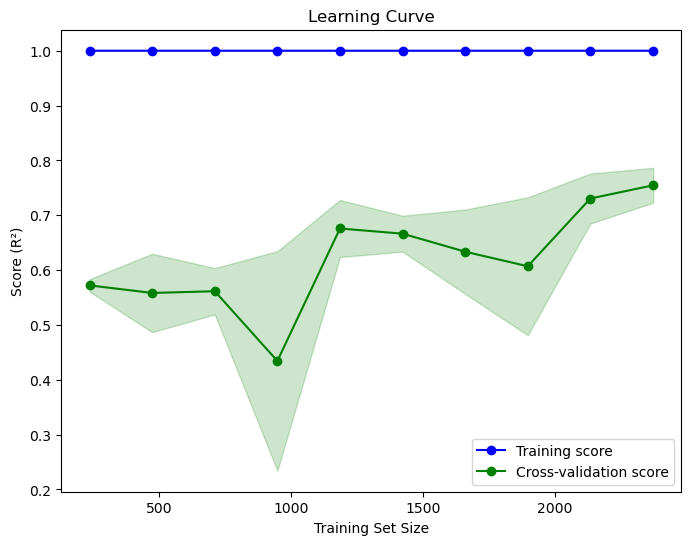

In [828]:
train_sizes, train_scores, test_scores = learning_curve(model1, X, y, cv=3, scoring= 'r2', n_jobs=-1, 
                                                        train_sizes=np.linspace(0.1, 1.0, 10))
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training score")
plt.plot(train_sizes, test_mean, 'o-', color="green", label="Cross-validation score")


plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color="blue")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color="green")

plt.xlabel("Training Set Size")
plt.ylabel("Score (R²)")
plt.title("Learning Curve")
plt.legend(loc="best")
plt.show()

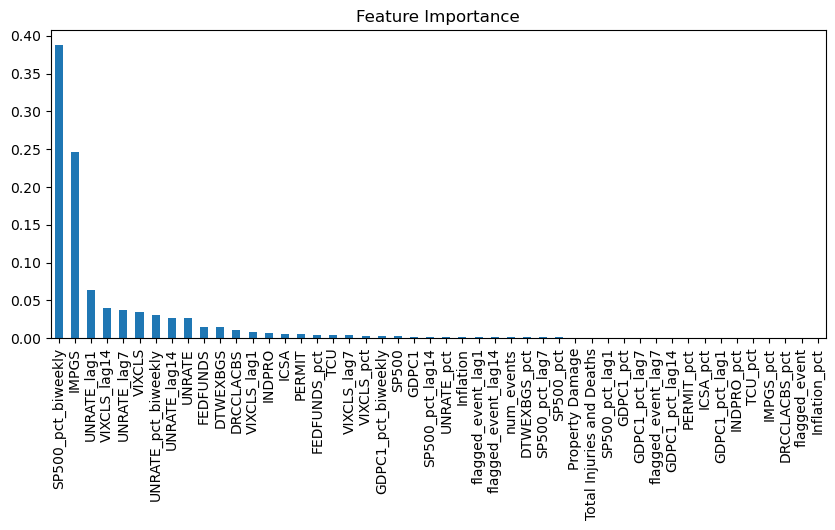

In [829]:
importances = model1.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

feat_imp.plot(kind="bar", figsize=(10,4))
plt.title("Feature Importance")
plt.show()

In [830]:
df2['SP500_pct_monthly'] = df2['SP500_pct'].rolling(window=30).sum()
df2['VIXCLS_pct_monthly'] = df2['VIXCLS_pct'].rolling(window=30).sum()
df2['GDPC1_pct_monthly'] = df2['GDPC1_pct'].rolling(window=30).sum()
df2['UNRATE_pct_monthly'] = df2['UNRATE_pct'].rolling(window=30).sum()

In [831]:
df2.dropna(inplace=True)

In [832]:
def scale_data(df2, target_col, ignore_cols, train_ratio=0.8):
    X = df2.drop([target_col, 'observation_date'], axis=1)
    y = df2[target_col]

    train_size = int(len(df2) * train_ratio)
    X_train, X_test = X.iloc[:train_size].copy(), X.iloc[train_size:].copy()
    y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

    scaled_cols = [c for c in X.columns if c not in ignore_cols]
    scaler = StandardScaler()
    X_train[scaled_cols] = scaler.fit_transform(X_train[scaled_cols])
    X_test[scaled_cols] = scaler.transform(X_test[scaled_cols])

    scaler_y = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
    y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

    return X_train, X_test, y_train, y_test, y_train_scaled, y_test_scaled, scaler_y


In [833]:
target_cols = ["SP500_pct_monthly", "VIXCLS_pct_monthly", "GDPC1_pct_monthly", "UNRATE_pct_monthly"]

models = {
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "Linear Regression": LinearRegression()
}


param_grids = {
    "Random Forest": {"n_estimators": [100, 275], "max_depth": [5, 12]},
    "XGBoost": {"n_estimators": [100, 275], "learning_rate": [0.01, 0.1]},
    "Linear Regression": {}  
}


results = []
ignore_cols = ['flagged_event', 'flagged_event_lag1', 'flagged_event_lag7', 'flagged_event_lag14']

for target in target_cols:
    X_train, X_test, y_train, y_test, y_train_scaled, y_test_scaled, scaler_y = scale_data(df2, target, ignore_cols)


    for model_name, model in models.items():
        if param_grids[model_name]:
            grid = GridSearchCV(model, param_grids[model_name], cv=3, scoring="r2")
            grid.fit(X_train, y_train)
            best_model = grid.best_estimator_
            best_params = grid.best_params_
        else:
            model.fit(X_train, y_train)
            best_model = model
            best_params = "N/A"

        y_pred = best_model.predict(X_test)

        results.append({
            "Target": target,
            "Model": model_name,
            "Best Params": best_params,
            "Test R2": r2_score(y_test, y_pred)
        })

results_df = pd.DataFrame(results)
results_df.head()


,Target,Model,Best Params,Test R2
0,SP500_pct_monthly,Random Forest,"{'max_depth': 12, 'n_estimators': 100}",0.640979
1,SP500_pct_monthly,XGBoost,"{'learning_rate': 0.1, 'n_estimators': 100}",0.662733
2,SP500_pct_monthly,Linear Regression,N/A,0.069402
3,VIXCLS_pct_monthly,Random Forest,"{'max_depth': 5, 'n_estimators': 100}",0.671849
4,VIXCLS_pct_monthly,XGBoost,"{'learning_rate': 0.01, 'n_estimators': 275}",0.636354


In [834]:
ordered_results = results_df.sort_values(by="Test R2", ascending=False)
ordered_results.head()

,Target,Model,Best Params,Test R2
3,VIXCLS_pct_monthly,Random Forest,"{'max_depth': 5, 'n_estimators': 100}",0.671849
1,SP500_pct_monthly,XGBoost,"{'learning_rate': 0.1, 'n_estimators': 100}",0.662733
0,SP500_pct_monthly,Random Forest,"{'max_depth': 12, 'n_estimators': 100}",0.640979
4,VIXCLS_pct_monthly,XGBoost,"{'learning_rate': 0.01, 'n_estimators': 275}",0.636354
2,SP500_pct_monthly,Linear Regression,N/A,0.069402


In [835]:
X = df2.drop(['SP500_pct_monthly', 'observation_date'], axis=1) 
y = df2['SP500_pct_monthly']

ignore_cols = ['flagged_event', 'flagged_event_lag1', 'flagged_event_lag7', 'flagged_event_lag14']
train_size = int(len(df2) * 0.8)
X_train, X_test = X.iloc[:train_size].copy(), X.iloc[train_size:].copy()
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

scaled_cols = [c for c in X.columns if c not in ignore_cols]
scaler = StandardScaler()
X_train[scaled_cols] = scaler.fit_transform(X_train[scaled_cols])
X_test[scaled_cols] = scaler.transform(X_test[scaled_cols])

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

model2 = XGBRegressor(learning_rate=0.1, n_estimators=275, random_state=42)

model2.fit(X_train, y_train_scaled)

y_pred_scaled = model2.predict(X_test)

y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

print(f'R Squared: {r2_score(y_test, y_pred)}') 
print(f'MAE: {mean_absolute_error(y_test, y_pred)}') 
print(f'MSE: {mean_squared_error(y_test, y_pred)}') 
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}')  

mod_res.append({
            "Model": "Model2",
            "Test R2": r2_score(y_test, y_pred)
        })

R Squared: 0.6726443070187726
MAE: 0.01789029681825457
MSE: 0.0005190750022613308
RMSE: 0.022783217557257596


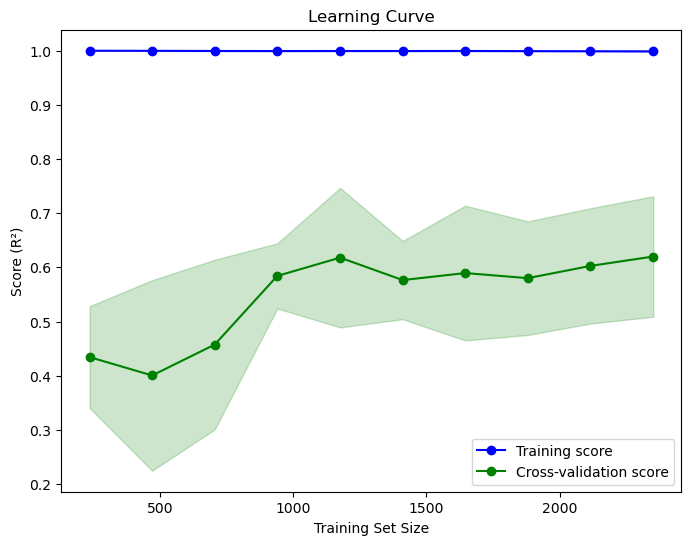

In [836]:
train_sizes, train_scores, test_scores = learning_curve(model2, X, y, cv=3, scoring= 'r2', n_jobs=-1, 
                                                        train_sizes=np.linspace(0.1, 1.0, 10))
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training score")
plt.plot(train_sizes, test_mean, 'o-', color="green", label="Cross-validation score")


plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color="blue")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color="green")

plt.xlabel("Training Set Size")
plt.ylabel("Score (R²)")
plt.title("Learning Curve")
plt.legend(loc="best")
plt.show()

In [837]:
X = df2.drop(['VIXCLS_pct_monthly', 'observation_date'], axis=1) 
y = df2['VIXCLS_pct_monthly']

ignore_cols = ['flagged_event', 'flagged_event_lag1', 'flagged_event_lag7', 'flagged_event_lag14']
train_size = int(len(df2) * 0.8)
X_train, X_test = X.iloc[:train_size].copy(), X.iloc[train_size:].copy()
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

scaled_cols = [c for c in X.columns if c not in ignore_cols]
scaler = StandardScaler()
X_train[scaled_cols] = scaler.fit_transform(X_train[scaled_cols])
X_test[scaled_cols] = scaler.transform(X_test[scaled_cols])

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

model3 = RandomForestRegressor(max_depth=5, n_estimators=100, random_state=42)

model3.fit(X_train, y_train_scaled)

y_pred_scaled = model3.predict(X_test)

y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

print(f'R Squared: {r2_score(y_test, y_pred)}') 
print(f'MAE: {mean_absolute_error(y_test, y_pred)}') 
print(f'MSE: {mean_squared_error(y_test, y_pred)}') 
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}')  

mod_res.append({
            "Model": "Model3",
            "Test R2": r2_score(y_test, y_pred)
        })

R Squared: 0.6726997690686637
MAE: 0.13153970365674417
MSE: 0.027645673190025342
RMSE: 0.1662698805858275


In [ ]:
train_sizes, train_scores, test_scores = learning_curve(model4, X, y, cv=3, scoring= 'r2', n_jobs=-1, 
                                                        train_sizes=np.linspace(0.1, 1.0, 10))
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training score")
plt.plot(train_sizes, test_mean, 'o-', color="green", label="Cross-validation score")


plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color="blue")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color="green")

plt.xlabel("Training Set Size")
plt.ylabel("Score (R²)")
plt.title("Learning Curve")
plt.legend(loc="best")
plt.show()

In [ ]:
importances = model3.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

feat_imp.plot(kind="bar", figsize=(10,4))
plt.title("Feature Importance")
plt.show()

In [840]:
df2['SP500_pct_quarterly'] = df2['SP500_pct'].rolling(window=90).sum()
df2['VIXCLS_pct_quarterly'] = df2['VIXCLS_pct'].rolling(window=90).sum()
df2['GDPC1_pct_quarterly'] = df2['GDPC1_pct'].rolling(window=90).sum()
df2['UNRATE_pct_quarterly'] = df2['UNRATE_pct'].rolling(window=90).sum()

In [841]:
df2.dropna(inplace=True)

In [842]:
def scale_data(df2, target_col, ignore_cols, train_ratio=0.8):
    X = df2.drop([target_col, 'observation_date'], axis=1)
    y = df2[target_col]

    train_size = int(len(df2) * train_ratio)
    X_train, X_test = X.iloc[:train_size].copy(), X.iloc[train_size:].copy()
    y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

    scaled_cols = [c for c in X.columns if c not in ignore_cols]
    scaler = StandardScaler()
    X_train[scaled_cols] = scaler.fit_transform(X_train[scaled_cols])
    X_test[scaled_cols] = scaler.transform(X_test[scaled_cols])

    scaler_y = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
    y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

    return X_train, X_test, y_train, y_test, y_train_scaled, y_test_scaled, scaler_y


In [843]:
target_cols = ["SP500_pct_quarterly", "VIXCLS_pct_quarterly", "GDPC1_pct_quarterly", "UNRATE_pct_quarterly"]

models = {
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "Linear Regression": LinearRegression()
}


param_grids = {
    "Random Forest": {"n_estimators": [100, 275], "max_depth": [5, 12]},
    "XGBoost": {"n_estimators": [100, 275], "learning_rate": [0.01, 0.1]},
    "Linear Regression": {}  
}


results2 = []
ignore_cols = ['flagged_event', 'flagged_event_lag1', 'flagged_event_lag7', 'flagged_event_lag14']

for target in target_cols:
    X_train, X_test, y_train, y_test, y_train_scaled, y_test_scaled, scaler_y = scale_data(df2, target, ignore_cols)


    for model_name, model in models.items():
        if param_grids[model_name]:
            grid = GridSearchCV(model, param_grids[model_name], cv=3, scoring="r2")
            grid.fit(X_train, y_train)
            best_model = grid.best_estimator_
            best_params = grid.best_params_
        else:
            model.fit(X_train, y_train)
            best_model = model
            best_params = "N/A"

        y_pred = best_model.predict(X_test)

        results2.append({
            "Target": target,
            "Model": model_name,
            "Best Params": best_params,
            "Test R2": r2_score(y_test, y_pred)
        })

results_df2 = pd.DataFrame(results2)
results_df2.head()

,Target,Model,Best Params,Test R2
0,SP500_pct_quarterly,Random Forest,"{'max_depth': 12, 'n_estimators': 275}",-0.058220
1,SP500_pct_quarterly,XGBoost,"{'learning_rate': 0.01, 'n_estimators': 100}",0.373055
2,SP500_pct_quarterly,Linear Regression,N/A,-0.907815
3,VIXCLS_pct_quarterly,Random Forest,"{'max_depth': 12, 'n_estimators': 275}",0.325296
4,VIXCLS_pct_quarterly,XGBoost,"{'learning_rate': 0.01, 'n_estimators': 100}",0.239264


In [844]:
ordered_results2 = results_df2.sort_values(by="Test R2", ascending=False)
ordered_results2.head()

,Target,Model,Best Params,Test R2
5,VIXCLS_pct_quarterly,Linear Regression,N/A,0.684230
1,SP500_pct_quarterly,XGBoost,"{'learning_rate': 0.01, 'n_estimators': 100}",0.373055
3,VIXCLS_pct_quarterly,Random Forest,"{'max_depth': 12, 'n_estimators': 275}",0.325296
10,UNRATE_pct_quarterly,XGBoost,"{'learning_rate': 0.01, 'n_estimators': 275}",0.296645
4,VIXCLS_pct_quarterly,XGBoost,"{'learning_rate': 0.01, 'n_estimators': 100}",0.239264


In [845]:
X = df2.drop(['VIXCLS_pct_quarterly', 'observation_date'], axis=1) 
y = df2['VIXCLS_pct_quarterly']

ignore_cols = ['flagged_event', 'flagged_event_lag1', 'flagged_event_lag7', 'flagged_event_lag14']
train_size = int(len(df2) * 0.8)
X_train, X_test = X.iloc[:train_size].copy(), X.iloc[train_size:].copy()
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

scaled_cols = [c for c in X.columns if c not in ignore_cols]
scaler = StandardScaler()
X_train[scaled_cols] = scaler.fit_transform(X_train[scaled_cols])
X_test[scaled_cols] = scaler.transform(X_test[scaled_cols])

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

model4 = LinearRegression()

model4.fit(X_train, y_train_scaled)

y_pred_scaled = model4.predict(X_test)

y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

print(f'R Squared: {r2_score(y_test, y_pred)}') 
print(f'MAE: {mean_absolute_error(y_test, y_pred)}') 
print(f'MSE: {mean_squared_error(y_test, y_pred)}') 
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}') 

mod_res.append({
            "Model": "Model4",
            "Test R2": r2_score(y_test, y_pred)
        })

R Squared: 0.6842301005467932
MAE: 0.16757359899613544
MSE: 0.050546060036599866
RMSE: 0.22482450942145935


In [ ]:
train_sizes, train_scores, test_scores = learning_curve(model5, X, y, cv=3, scoring= 'r2', n_jobs=-1, 
                                                        train_sizes=np.linspace(0.1, 1.0, 10))
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training score")
plt.plot(train_sizes, test_mean, 'o-', color="green", label="Cross-validation score")


plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color="blue")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color="green")

plt.xlabel("Training Set Size")
plt.ylabel("Score (R²)")
plt.title("Learning Curve")
plt.legend(loc="best")
plt.show()

In [ ]:
importances = model5.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

feat_imp.plot(kind="bar", figsize=(10,4))
plt.title("Feature Importance")
plt.show()

In [856]:
X = df2.drop(['VIXCLS_pct_quarterly', 'observation_date'], axis=1) 
y = df2['VIXCLS_pct_quarterly']

ignore_cols = ['flagged_event', 'flagged_event_lag1', 'flagged_event_lag7', 'flagged_event_lag14']
train_size = int(len(df2) * 0.8)
X_train, X_test = X.iloc[:train_size].copy(), X.iloc[train_size:].copy()
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

scaled_cols = [c for c in X.columns if c not in ignore_cols]
scaler = StandardScaler()
X_train[scaled_cols] = scaler.fit_transform(X_train[scaled_cols])
X_test[scaled_cols] = scaler.transform(X_test[scaled_cols])

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

model5 = RandomForestRegressor(max_depth=12, n_estimators=100, random_state=42)

model5.fit(X_train, y_train_scaled)

y_pred_scaled = model5.predict(X_test)

y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

print(f'R Squared: {r2_score(y_test, y_pred)}') 
print(f'MAE: {mean_absolute_error(y_test, y_pred)}') 
print(f'MSE: {mean_squared_error(y_test, y_pred)}') 
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}') 

mod_res.append({
            "Model": "Model5",
            "Test R2": r2_score(y_test, y_pred)
        })

R Squared: 0.3091258510666983
MAE: 0.2522674991156037
MSE: 0.11058991458713231
RMSE: 0.33255061958615006


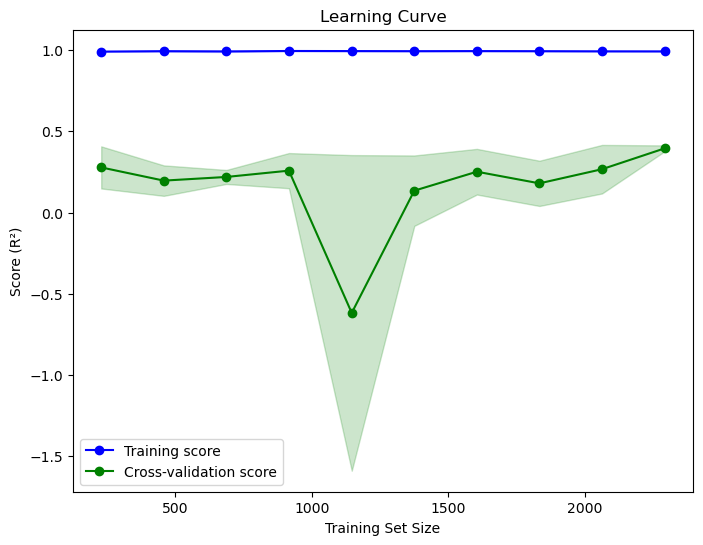

In [857]:
train_sizes, train_scores, test_scores = learning_curve(model5, X, y, cv=3, scoring= 'r2', n_jobs=-1, 
                                                        train_sizes=np.linspace(0.1, 1.0, 10))
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training score")
plt.plot(train_sizes, test_mean, 'o-', color="green", label="Cross-validation score")


plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color="blue")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color="green")

plt.xlabel("Training Set Size")
plt.ylabel("Score (R²)")
plt.title("Learning Curve")
plt.legend(loc="best")
plt.show()

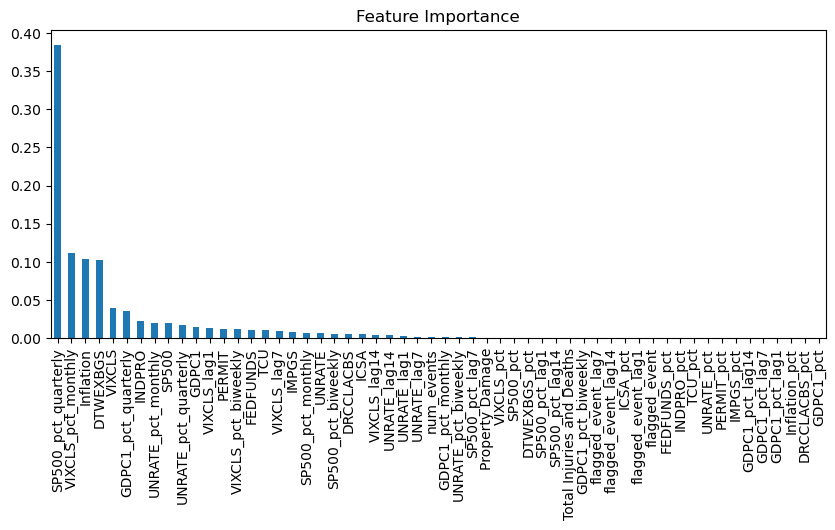

In [858]:
importances = model5.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

feat_imp.plot(kind="bar", figsize=(10,4))
plt.title("Feature Importance")
plt.show()

In [872]:
target = df2['VIXCLS_pct_quarterly']
exog = df2[['flagged_event']]
model6 = ARIMA(target, exog=exog, order=(2,1,1))
fit = model6.fit()

print(fit.summary())

C:\Users\Miranda\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Miranda\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Miranda\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Miranda\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\Miranda\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting M

                                SARIMAX Results                                 
Dep. Variable:     VIXCLS_pct_quarterly   No. Observations:                 3439
Model:                   ARIMA(2, 1, 1)   Log Likelihood                2976.081
Date:                  Wed, 10 Sep 2025   AIC                          -5942.163
Time:                          20:34:14   BIC                          -5911.449
Sample:                               0   HQIC                         -5931.191
                                 - 3439                                         
Covariance Type:                    opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
flagged_event     0.0078      0.004      1.749      0.080      -0.001       0.017
ar.L1            -0.9451      0.100     -9.465      0.000      -1.141      -0.749
ar.L2            -0.0914

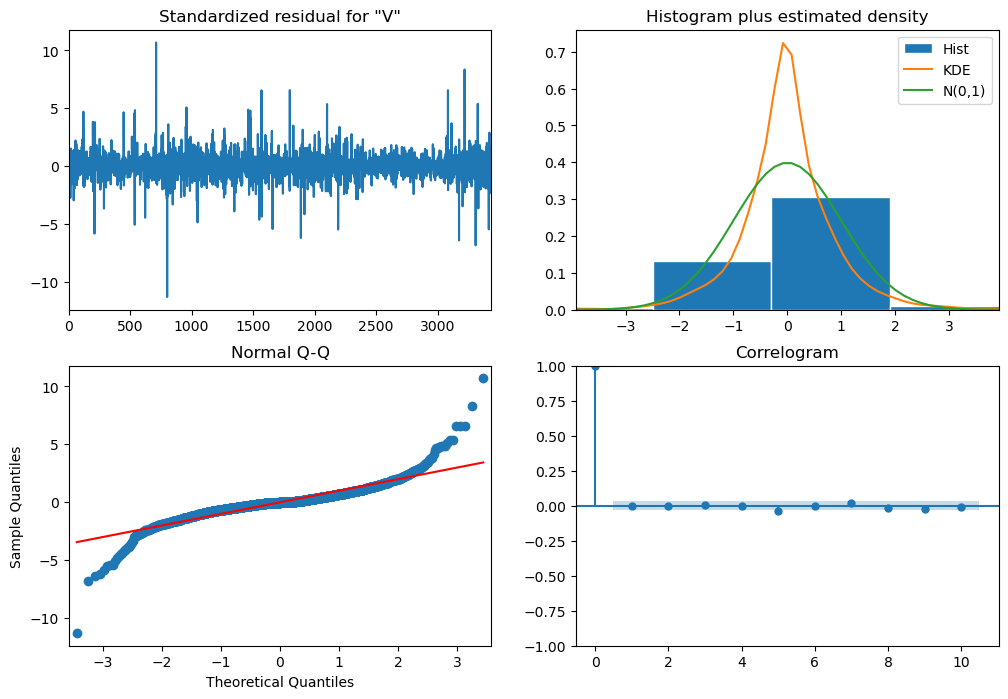

In [875]:
fit.plot_diagnostics(figsize=(12,8))
plt.show()


Our residuals are not autocorrelated or normally distributed, from the bottom two graphs. 

## Results and Conclusion

In [866]:
mod_res = pd.DataFrame(mod_res)
mod_res_ordered = mod_res.sort_values(by="Test R2", ascending=False)
mod_res_ordered.head()

,Model,Test R2
0,Model1,0.790492
3,Model4,0.684230
2,Model3,0.672700
1,Model2,0.672644
4,Model5,0.309126


Model1 and model4 have the highest R2 scores. The learning curve graphs for these models suggest that with more data, they can preform even better. There are some overfitting issues. I would like to explore this more in the future with more data. Weather data seems to have little to no importance as a feature in regression models. Flagged events may be slightly impactful according to the coefficent (p=0.08), but overall the model fits the data well. 